# 04: 量子フーリエ変換 (QFT) — 回路の実装

ノート `04_discrete_fourier_transform.md` で導入した離散フーリエ変換 (DFT) を、量子回路として実現する。

**内容:**
1. $N = 2$（1量子ビット）の QFT — アダマールゲートとの一致
2. $N = 4$（2量子ビット）の QFT — 行列の確認と具体例
3. Qiskit の `QFT` ライブラリとの比較

> **記法の注意:** ノートと Qiskit ではインデックスの始まり（1 vs 0）やケット表記のビット順が異なる。詳しくは [01_qubit_ordering.ipynb](01_qubit_ordering.ipynb) を参照。物理的な結果には影響しない。

In [24]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import QFTGate
import numpy as np

## 1. $N = 2$（1量子ビット）の QFT

ノート04で示した通り、$N = 2$ の DFT 行列は：

$$
F_2 = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}
$$

これはアダマールゲート $H$ そのものである。1量子ビットの QFT は $H$ ゲート1つで実現できる。

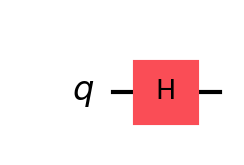

In [25]:
# 1量子ビットの QFT = アダマールゲート
qc_qft1 = QuantumCircuit(1)
qc_qft1.h(0)

print(f"1量子ビット QFT 回路: ゲート数 {qc_qft1.size()}")

1量子ビット QFT 回路: ゲート数 1


In [26]:
# H ゲートの行列を確認
H_matrix = Operator(qc_qft1).data
print("H ゲートの行列:")
print(np.array(H_matrix).round(4))

# F_2 を手計算で構築
F2 = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]])
print("\nF_2（DFT 行列）:")
print(F2.round(4))

print(f"\n一致するか: {np.allclose(H_matrix, F2)}")
print("→ 1量子ビットの QFT はアダマールゲートそのもの。")

H ゲートの行列:
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]

F_2（DFT 行列）:
[[ 0.7071  0.7071]
 [ 0.7071 -0.7071]]

一致するか: True
→ 1量子ビットの QFT はアダマールゲートそのもの。


**コードの解説:**

- `Operator(qc_qft1).data`: 回路全体をユニタリ行列として取得する。1量子ビットなので $2 \times 2$ 行列。
- `np.allclose`: 2つの行列が数値的に一致するか判定する。

In [27]:
# |0⟩ と |1⟩ に QFT を適用してみる
for label, init in [("0", None), ("1", "x")]:
    qc = QuantumCircuit(1)
    if init == "x":
        qc.x(0)  # |1⟩ を準備
    qc.h(0)  # QFT = H
    sv = Statevector.from_instruction(qc)
    print(f"QFT|{label}⟩ = ", end="")
    for i, amp in enumerate(sv):
        if i > 0:
            print(" + ", end="")
        print(f"({amp:.4f})|{i}⟩", end="")
    print()

print()
print("→ |0⟩ は均等な重ね合わせ |+⟩ になる。")
print("  |1⟩ は符号が反転した |−⟩ になる。")

QFT|0⟩ = (0.7071+0.0000j)|0⟩ + (0.7071+0.0000j)|1⟩
QFT|1⟩ = (0.7071+0.0000j)|0⟩ + (-0.7071+0.0000j)|1⟩

→ |0⟩ は均等な重ね合わせ |+⟩ になる。
  |1⟩ は符号が反転した |−⟩ になる。


## 2. $N = 4$（2量子ビット）の QFT

ノート04の $F_4$ 行列：

$$
F_4 = \frac{1}{2} \begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & i & -1 & -i \\
1 & -1 & 1 & -1 \\
1 & -i & -1 & i
\end{pmatrix}
$$

2量子ビットの QFT 回路は、$H$、制御位相ゲート、SWAP で構成される。

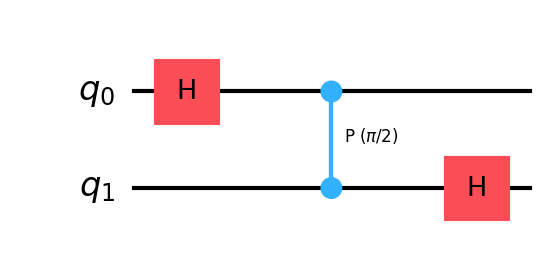

In [ ]:
# 2量子ビットの QFT を手動で構築（SWAP なし、Qiskit のビット順のまま）
qc_qft2 = QuantumCircuit(2)
qc_qft2.h(0)                          # q_0 に H
qc_qft2.cp(np.pi / 2, 1, 0)           # 制御位相ゲート R_2 (制御: q_1, 標的: q_0)
qc_qft2.h(1)                          # q_1 に H

print(f"2量子ビット QFT 回路: ゲート数 {qc_qft2.size()}")

**コードの解説:**

- `qc.cp(np.pi / 2, 1, 0)`: 制御位相ゲート。$q_0$ と $q_1$ の両方が $\vert 1\rangle$ のときだけ位相 $e^{i\pi/2} = i$ を掛ける。これは $R_2 = \text{diag}(1, e^{2\pi i / 2^2})$ に対応する。

ここでは SWAP を入れず、Qiskit のビット順のままにしている。QFT の回路は構造上、出力ビットが教科書と逆順になるが、Qiskit の世界では問題ない。教科書の $F_4$ と行列比較するときだけ、ビット順の違いを考慮する（次のセルで確認する）。

**制御位相ゲートの対称性について:**

回路図で `P(π/2)` が $q_0$ と $q_1$ の間に対称的に描かれており、どちらが制御ビットかわからないように見える。実は制御位相ゲートは制御と標的を入れ替えても結果が同じである。その理由は、位相が掛かるのが $\vert 11\rangle$（両方が 1）のときだけだからである。

$$
CP = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & e^{i\theta} \end{pmatrix}
$$

$\vert 01\rangle$ にも $\vert 10\rangle$ にも位相は掛からない。「どちらかのビットが位相的に進む（遅れる）」のではなく、**2つのビットの組み合わせ $\vert 11\rangle$ という状態全体に位相が付く**。だからこそ $q_0$ と $q_1$ の役割は対称であり、回路図でも区別なく描かれている。

In [ ]:
# 回路のユニタリ行列を取得
U_qft2 = Operator(qc_qft2).data
print("手動構築した QFT 回路の行列（SWAP なし）:")
print(np.array(U_qft2).round(4))

# F_4 を手計算で構築（教科書の量子ビット順: q_0 が最上位ビット）
# Python では 1j が虚数単位 i を表す（例: 2 * 1j = 2i）
omega4 = np.exp(2 * 1j * np.pi / 4)  # ω_4 = i
F4 = (1 / 2) * np.array([
    [1, 1, 1, 1],
    [1, omega4, omega4**2, omega4**3],
    [1, omega4**2, omega4**4, omega4**6],
    [1, omega4**3, omega4**6, omega4**9],
])
print("\nF_4（DFT 行列, 教科書の量子ビット順）:")
print(F4.round(4))

# SWAP なしの回路行列は、教科書の F_4 に対して2つのビット順の違いがある:
#   (1) Qiskit のリトルエンディアン（q_0 が最下位ビット）
#   (2) QFT 回路構造上の出力ビット逆順
# 2量子ビットではこの2つはどちらも index 1 ↔ 2 の入れ替えなので、
# 置換行列 P を右から掛ける（入力のビット順を教科書に合わせる）と一致する。
P = np.array([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
])

print(f"\n教科書の量子ビット順に揃えて一致するか: {np.allclose(U_qft2 @ P, F4)}")

### 具体例: ノート04 の計算を回路で再現

ノート04で手計算した3つの例を、QFT 回路のシミュレーションで確認する。

入力状態を `initialize` で準備してから、セクション2と同じ QFT ゲート列を適用する。

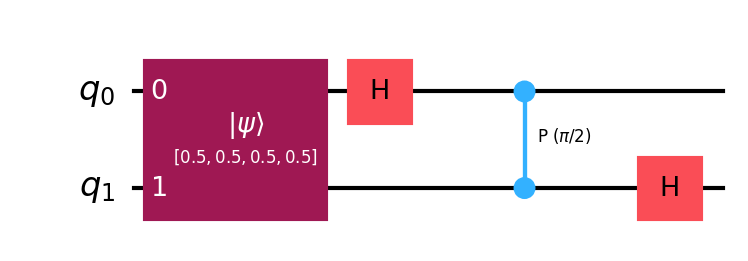

In [ ]:
def apply_qft_and_show(input_vec, label):
    """入力状態に QFT を適用し、結果を表示する。"""
    qc = QuantumCircuit(2)
    qc.initialize(input_vec, [0, 1])
    # QFT を適用（手動構築と同じゲート列、SWAP なし）
    qc.h(0)
    qc.cp(np.pi / 2, 1, 0)
    qc.h(1)
    
    sv = Statevector.from_instruction(qc)
    
    print(f"入力: {label}")
    print(f"  入力ベクトル: {np.array(input_vec).round(4)}")
    print(f"  QFT 出力:     {np.array(sv).round(4)}")
    print()


# 例 1: 均等な入力 (1/2, 1/2, 1/2, 1/2)
apply_qft_and_show([0.5, 0.5, 0.5, 0.5], "|x⟩ = (1/2)(|0⟩+|1⟩+|2⟩+|3⟩)")

# 例 2: |0⟩ だけ（デルタ関数）
apply_qft_and_show([1, 0, 0, 0], "|x⟩ = |0⟩")

# 例 3: 交互パターン (1/2, -1/2, 1/2, -1/2)
apply_qft_and_show([0.5, -0.5, 0.5, -0.5], "|x⟩ = (1/2)(|0⟩-|1⟩+|2⟩-|3⟩)")

## 3. Qiskit の `QFTGate` との比較

Qiskit には `QFTGate` クラスが用意されている。手動で構築した回路と同じ行列を生成するか確認する。

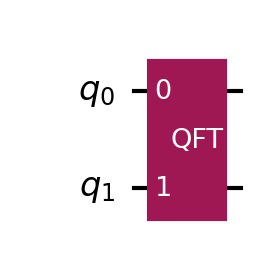

In [ ]:
# Qiskit の QFTGate（2量子ビット）
qft_lib = QFTGate(2)

print(f"Qiskit QFTGate: {qft_lib.num_qubits} 量子ビット")

**コードの解説:**

- `QFTGate(2)`: 2量子ビットの QFT ゲートを生成する。引数はビット数。
- `QFTGate(2).inverse()` とすれば逆 QFT（$F_N^\dagger$）が得られる。QPE（ノート05）で使用する。

In [ ]:
# ライブラリ版の行列を取得
U_lib = Operator(qft_lib).data
print("Qiskit QFTGate の行列:")
print(np.array(U_lib).round(4))

print(f"\n手動構築の回路と一致: {np.allclose(U_qft2, U_lib)}")
print(f"F_4 行列と一致:       {np.allclose(U_lib, F4)}")

### 逆 QFT の確認

QFT は DFT 行列 $F_N$ をそのまま量子回路にしたもの。逆 QFT は $F_N^\dagger$（エルミート共役）であり、$F_N^\dagger F_N = I$（恒等演算子）となる。

これをシミュレーションで確認する。

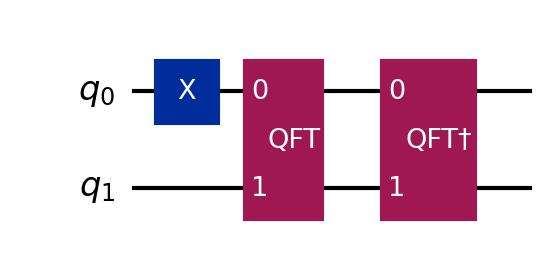

In [ ]:
# QFT → 逆 QFT を連続で適用すると元に戻るか確認
qc_roundtrip = QuantumCircuit(2)
qc_roundtrip.x(0)  # |01⟩ = |1⟩ を準備（非自明な入力）

# QFT を適用
qft_gate = QFTGate(2)
qc_roundtrip.append(qft_gate, [0, 1])

# 逆 QFT を適用
iqft_gate = QFTGate(2).inverse()
qc_roundtrip.append(iqft_gate, [0, 1])

print(f"ラウンドトリップ回路: {qc_roundtrip.num_qubits} 量子ビット, ゲート数 {qc_roundtrip.size()}")

In [19]:
sv_roundtrip = Statevector.from_instruction(qc_roundtrip)

print("QFT → 逆 QFT 後の状態ベクトル:")
print(f"  {np.array(sv_roundtrip).round(4)}")
print()

# 元の |01⟩ と一致するか
expected = np.array([0, 1, 0, 0], dtype=complex)  # |01⟩ (index 1)
print(f"元の |1⟩ と一致: {np.allclose(sv_roundtrip, expected)}")
print("→ QFT の後に逆 QFT を掛けると、元の状態に戻る。")

QFT → 逆 QFT 後の状態ベクトル:
  [0.+0.j 1.+0.j 0.-0.j 0.+0.j]

元の |1⟩ と一致: True
→ QFT の後に逆 QFT を掛けると、元の状態に戻る。
